In [1]:
import pandas as pd
df = pd.read_csv("/content/drive/MyDrive/final.csv")


#################################################################
  HAV GRID SEARCH  —  2×3×2×2 configurations
#################################################################
--- Preparing data (once) ---

[HAV-BASE | OLS | log | h=1]
          Coef.  Std.Err.         t         P>|t|    [0.025    0.975]
const -3.144253  0.369601 -8.507163  2.756866e-17 -3.868946 -2.419560
x1     0.026205  0.020539  1.275896  2.020900e-01 -0.014066  0.066476
x2    -0.066183  0.048254 -1.371559  1.703020e-01 -0.160796  0.028430
x3     0.562699  0.070105  8.026519  1.419209e-15  0.425241  0.700157
  ✓ HAV-BASE|OLS|log|h=1

[HAV-BASE | OLS | log | h=5]
          Coef.  Std.Err.          t         P>|t|    [0.025    0.975]
const -3.269757  0.183769 -17.792803  1.936043e-67 -3.630081 -2.909434
x1     0.017229  0.010216   1.686456  9.181100e-02 -0.002802  0.037260
x2     0.039956  0.024023   1.663252  9.636536e-02 -0.007147  0.087059
x3     0.446791  0.034873  12.812050  1.233148e-36  0.378414  0.515168
  

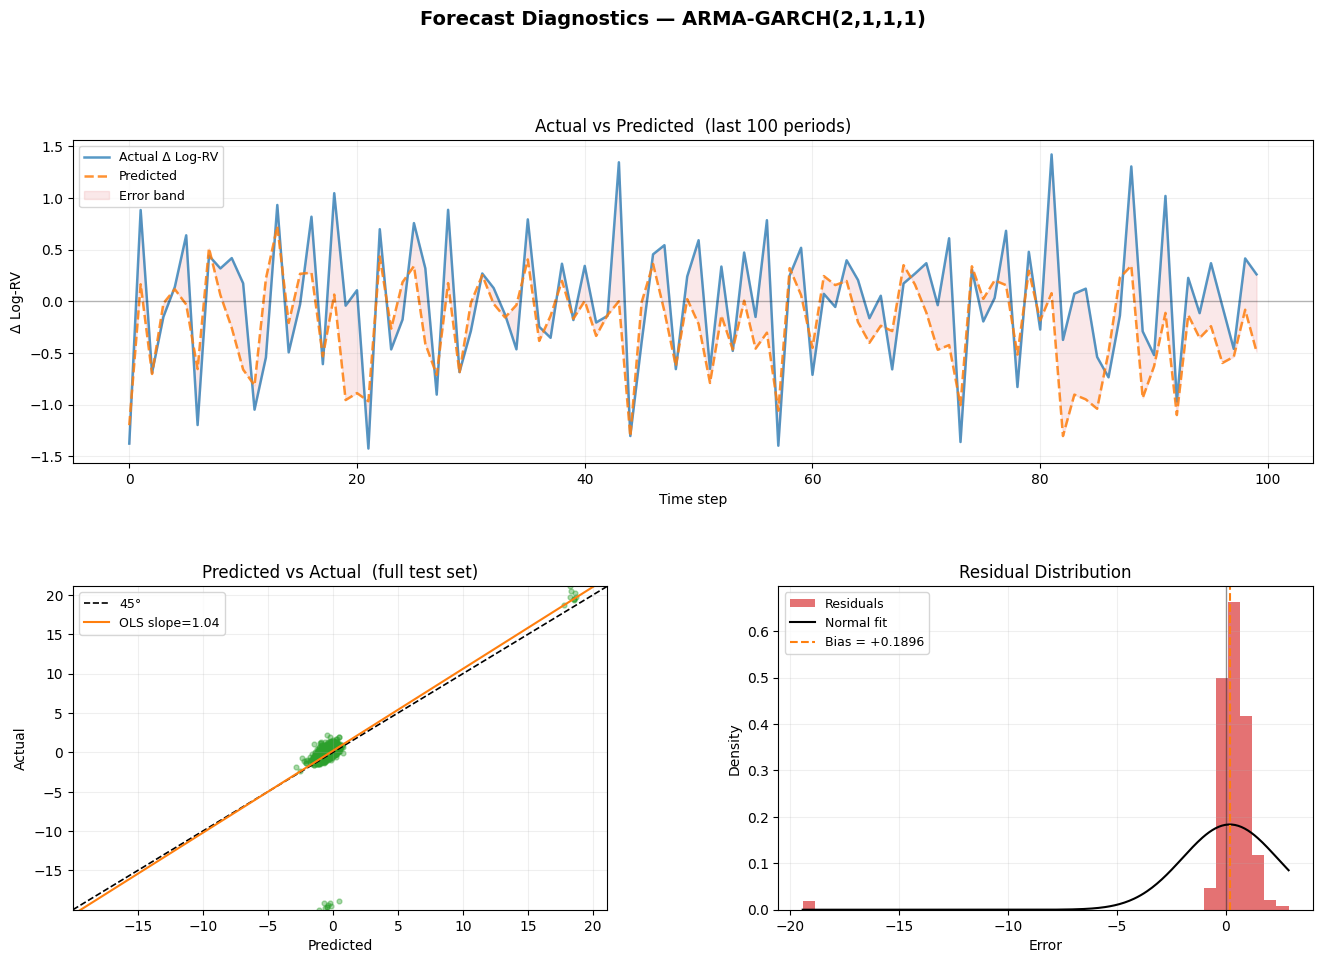

In [3]:
# =============================================================================
#  STANDALONE HAV & ARMA-GARCH VOLATILITY MODELS
#  Drop-in compatible with the CNN+MLP+LGBM blend pipeline
# =============================================================================

import numpy as np
import pandas as pd
import statsmodels.api as sm
from scipy.optimize import minimize
from scipy.stats import norm, spearmanr, pearsonr
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler, RobustScaler
import warnings
warnings.filterwarnings('ignore')

# Reuse pipeline constants
LAG_DAILY    = 5
LAG_WEEKLY   = 20
LAG_MONTHLY  = 50
N_FACTORS    = 3


# =============================================================================
#  SHARED UTILITIES  (copied from main pipeline for standalone use)
# =============================================================================

def preprocess_and_downsample(df):
    time_order = df['time_id'].unique()
    time_rank  = {tid: i for i, tid in enumerate(time_order)}
    df = (df.assign(time_rank=df['time_id'].map(time_rank))
            .sort_values(['time_rank', 'seconds_in_bucket']))

    result = (df.drop(columns='time_rank')
                .reset_index(drop=True))

    old_to_new = {tid: i for i, tid in enumerate(time_order)}
    result['time_id_orig'] = result['time_id']
    result['time_id']      = result['time_id'].map(old_to_new)
    return result


def compute_log_rv_matrix(df_down):
    stock_cols = [c for c in df_down.columns
                  if c not in ['time_id', 'seconds_in_bucket',
                                'time_id_orig']]

    def get_rv(group):
        log_prices = np.log(group[stock_cols].replace(0, np.nan)).ffill()
        log_ret    = log_prices.diff().dropna()
        rv         = np.sqrt((log_ret ** 2).sum())
        return np.log(rv + 1e-11)

    full_rv = df_down.groupby('time_id')[stock_cols].apply(get_rv)
    return full_rv, stock_cols


def evaluate_forecast(y_true: np.ndarray, y_pred: np.ndarray,
                      label: str = 'Model') -> dict:
    """Identical metric suite to the main pipeline."""
    eps = 1e-8
    err = y_true - y_pred

    mae   = np.mean(np.abs(err))
    rmse  = np.sqrt(np.mean(err ** 2))
    r2    = r2_score(y_true, y_pred)
    mape  = np.mean(np.abs(err) / (np.abs(y_true) + eps)) * 100
    smape = np.mean(2 * np.abs(err) /
                    (np.abs(y_true) + np.abs(y_pred) + eps)) * 100

    rv_true = np.clip(y_true, eps, None)
    rv_pred = np.clip(y_pred, eps, None)
    qlike   = np.mean(rv_true / rv_pred - np.log(rv_true / rv_pred) - 1)

    naive_err = y_true[1:] - y_true[:-1]
    model_err = err[1:]
    theils_u2 = (np.sqrt(np.mean(model_err ** 2)) /
                 (np.sqrt(np.mean(naive_err ** 2)) + eps))

    X_mz  = sm.add_constant(y_pred)
    mz    = sm.OLS(y_true, X_mz).fit()
    mz_r2 = mz.rsquared
    mz_intercept, mz_slope = mz.params

    hit_rate     = np.mean(np.sign(y_true) == np.sign(y_pred)) * 100
    correct_mask = np.sign(y_true) == np.sign(y_pred)
    dir_r2       = (r2_score(y_true[correct_mask], y_pred[correct_mask])
                    if correct_mask.sum() > 1 else np.nan)

    thresh_90   = np.quantile(np.abs(y_true), 0.90)
    thresh_95   = np.quantile(np.abs(y_true), 0.95)
    mask_90     = np.abs(y_true) >= thresh_90
    mask_95     = np.abs(y_true) >= thresh_95
    tail_mae_90 = np.mean(np.abs(err[mask_90])) if mask_90.sum() > 0 else np.nan
    tail_mae_95 = np.mean(np.abs(err[mask_95])) if mask_95.sum() > 0 else np.nan

    spearman_r, _ = spearmanr(y_true, y_pred)
    pearson_r,  _ = pearsonr(y_true,  y_pred)

    bias     = np.mean(err)
    bias_pct = bias / (np.mean(np.abs(y_true)) + eps) * 100

    metrics = {
        'MAE':          mae,   'RMSE':         rmse,  'R²':           r2,
        'MAPE (%)':     mape,  'SMAPE (%)':    smape, 'QLIKE':        qlike,
        "Theil's U2":   theils_u2,
        'MZ R²':        mz_r2, 'MZ Intercept': mz_intercept,
        'MZ Slope':     mz_slope,
        'Hit Rate (%)': hit_rate,  'Dir R²':   dir_r2,
        'Tail MAE 90':  tail_mae_90, 'Tail MAE 95': tail_mae_95,
        'Spearman r':   spearman_r,  'Pearson r':   pearson_r,
        'Bias':         bias,        'Bias (%)':    bias_pct,
    }

    col_w = 18
    print(f"\n{'='*42}")
    print(f"  Forecast Metrics — {label}")
    print(f"{'='*42}")
    print(f"  {'Metric':<{col_w}}  Value")
    print(f"  {'-'*38}")
    for k, v in metrics.items():
        print(f"  {k:<{col_w}}  {v:+.4f}")
    print(f"{'='*42}\n")
    return metrics


# =============================================================================
#  MODEL 1 — HAV-RV  (Heterogeneous Autoregressive Realized Volatility)
# =============================================================================
#
#  Corsi (2009):
#      RV(t+1) = α + β_d·RV_d(t) + β_w·RV_w(t) + β_m·RV_m(t) + ε
#
#  where
#      RV_d(t)  = daily  lag  (t)
#      RV_w(t)  = weekly  avg (t-1 … t-5)
#      RV_m(t)  = monthly avg (t-1 … t-22)
#
#  Extensions implemented here:
#      HAV-RV-J  : + jump component  J(t)  = max(RV - BPV, 0)
#      HAV-RV-CJ : + continuous / jump decomposition (Andersen et al. 2007)
# =============================================================================

# ── Insanity filter (applied post-prediction) ─────────────────────────────────
def insanity_filter(preds: np.ndarray,
                    rv_history: np.ndarray,
                    lo_mult: float = 0.1,
                    hi_mult: float = 10.0) -> np.ndarray:
    """
    Cap forecasts to [lo_mult × hist_min, hi_mult × hist_max] in level space.
    Prevents pathological forecasts during regime changes.
    Applied on log-RV predictions by converting briefly to RV scale.

    Parameters
    ----------
    preds      : log-RV predictions
    rv_history : log-RV training history used to derive bounds
    lo_mult    : lower bound multiplier on historical minimum RV
    hi_mult    : upper bound multiplier on historical maximum RV
    """
    rv_hist   = np.exp(rv_history)
    lo        = np.log(lo_mult * np.nanmin(rv_hist[rv_hist > 0]) + 1e-11)
    hi        = np.log(hi_mult * np.nanmax(rv_hist) + 1e-11)
    clipped   = np.clip(preds, lo, hi)
    n_clipped = int(np.sum(clipped != preds))
    if n_clipped:
        print(f"  [InsanityFilter] Clipped {n_clipped}/{len(preds)} forecasts "
              f"to [{lo:.3f}, {hi:.3f}]")
    return clipped


class HAVModel:
    """
    Heterogeneous Autoregressive (HAV) model for Realized Volatility.

    Implements the improvements from the paper:
        "Forecasting Realized Volatility: HAR vs. Alternatives"

    Parameters
    ----------
    variant : str
        'base'  — Corsi (2009) 3-component HAV
        'j'     — HAV-RV-J  (adds raw jump component)
        'cj'    — HAV-RV-CJ (continuous + jump split on each horizon)
    estimator : str
        'ols'   — Ordinary Least Squares (baseline)
        'wls'   — Weighted Least Squares  (weights = 1/RV_d, downweights
                  calm periods, reduces over-prediction in volatile regimes)
        'rr'    — Ridge Regression        (L2 penalty; controls multicollinearity
                  between the highly correlated daily/weekly/monthly components)
    transform : str
        'log'   — Work in log-RV space (default; already Gaussian-ish)
        'sqrt'  — Square-root transformation
        'none'  — Raw RV (original scale; generally outperformed by log/sqrt)
    alpha_ridge : float
        Ridge penalty λ. Ignored when estimator != 'rr'.
    horizon : int
        Multi-step forecast horizon h. h=1 is one-step ahead.
        For h>1 the target becomes the h-period average RV (MIDAS-style
        aggregation, consistent with Corsi 2009 Section 3).
    d_lag : int   Daily lag.
    w_lag : int   Weekly rolling window.
    m_lag : int   Monthly rolling window.
    """

    VARIANTS   = ('base', 'j', 'cj')
    ESTIMATORS = ('ols', 'wls', 'rr')
    TRANSFORMS = ('log', 'sqrt', 'none')

    def __init__(self,
                 variant:     str   = 'base',
                 estimator:   str   = 'ols',
                 transform:   str   = 'log',
                 alpha_ridge: float = 1.0,
                 horizon:     int   = 1,
                 d_lag:       int   = 1,
                 w_lag:       int   = 5,
                 m_lag:       int   = 22):
        for val, pool, name in [
            (variant,   self.VARIANTS,   'variant'),
            (estimator, self.ESTIMATORS, 'estimator'),
            (transform, self.TRANSFORMS, 'transform'),
        ]:
            if val not in pool:
                raise ValueError(f"{name} must be one of {pool}")

        self.variant     = variant
        self.estimator   = estimator
        self.transform   = transform
        self.alpha_ridge = alpha_ridge
        self.horizon     = horizon
        self.d_lag       = d_lag
        self.w_lag       = w_lag
        self.m_lag       = m_lag

        self.params_:        np.ndarray | None = None
        self.feature_names_: list[str]         = []
        self._rv_train_:     np.ndarray | None = None   # kept for insanity filter

    # ------------------------------------------------------------------ #
    # Transform helpers                                                    #
    # ------------------------------------------------------------------ #

    def _apply_transform(self, log_rv: pd.Series) -> pd.Series:
        """Convert log-RV → working scale."""
        if self.transform == 'log':
            return log_rv                                   # already log-RV
        elif self.transform == 'sqrt':
            rv = np.exp(log_rv)
            return pd.Series(np.sqrt(np.clip(rv, 0, None)), index=log_rv.index)
        else:                                               # 'none' → raw RV
            return pd.Series(np.exp(log_rv), index=log_rv.index)

    def _invert_transform(self, preds: np.ndarray) -> np.ndarray:
        """Convert working-scale predictions back to log-RV space."""
        if self.transform == 'log':
            return preds
        elif self.transform == 'sqrt':
            return np.log(np.clip(preds ** 2, 1e-11, None))
        else:
            return np.log(np.clip(preds, 1e-11, None))

    # ------------------------------------------------------------------ #
    # Feature construction                                                 #
    # ------------------------------------------------------------------ #

    @staticmethod
    def _bipower_variation(log_rv_series: pd.Series) -> pd.Series:
        """BPV ≈ 0.9 × RV  (Barndorff-Nielsen 2004 simplified proxy)."""
        rv  = np.exp(log_rv_series)
        bpv = 0.90 * rv
        return pd.Series(np.log(bpv + 1e-11), index=log_rv_series.index)

    def _build_features(self, rv_work: pd.Series) -> pd.DataFrame:
        """
        Build HAV design matrix in the working (transformed) scale.
        rv_work is already transformed (log / sqrt / raw).
        """
        df = pd.DataFrame(index=rv_work.index)
        df['RV_d'] = rv_work.shift(self.d_lag)
        df['RV_w'] = rv_work.shift(1).rolling(self.w_lag).mean()
        df['RV_m'] = rv_work.shift(1).rolling(self.m_lag).mean()

        if self.variant in ('j', 'cj'):
            # Jump decomposition is always computed in log-RV space,
            # then transformed to the working scale.
            # We need the original log-RV to derive BPV.
            bpv = self._bipower_variation(
                pd.Series(np.log(np.clip(np.exp(rv_work.values), 1e-11, None)),
                          index=rv_work.index))
            jump_log = np.log(np.clip(np.exp(rv_work.values) - np.exp(bpv.values),
                                      1e-11, None))
            cont_log = bpv.values

            # Re-transform jump/continuous to working scale
            if self.transform == 'sqrt':
                jump_w = np.sqrt(np.clip(np.exp(jump_log), 0, None))
                cont_w = np.sqrt(np.clip(np.exp(cont_log), 0, None))
            elif self.transform == 'none':
                jump_w = np.exp(jump_log)
                cont_w = np.exp(cont_log)
            else:
                jump_w = jump_log
                cont_w = cont_log

            jump_s = pd.Series(jump_w, index=rv_work.index)
            cont_s = pd.Series(cont_w, index=rv_work.index)

            if self.variant == 'j':
                df['J_d'] = jump_s.shift(self.d_lag)

            elif self.variant == 'cj':
                df.drop(columns=['RV_d', 'RV_w', 'RV_m'], inplace=True)
                df['C_d'] = cont_s.shift(self.d_lag)
                df['J_d'] = jump_s.shift(self.d_lag)
                df['C_w'] = cont_s.shift(1).rolling(self.w_lag).mean()
                df['J_w'] = jump_s.shift(1).rolling(self.w_lag).mean()
                df['C_m'] = cont_s.shift(1).rolling(self.m_lag).mean()
                df['J_m'] = jump_s.shift(1).rolling(self.m_lag).mean()

        self.feature_names_ = list(df.columns)
        return df

    # ------------------------------------------------------------------ #
    # Multi-step target                                                    #
    # ------------------------------------------------------------------ #

    def _build_target(self, rv_work: pd.Series) -> pd.Series:
        """
        h-step-ahead target.
        h=1 : next period's RV  (standard)
        h>1 : h-period forward average (Corsi 2009 multi-step extension)
        """
        if self.horizon == 1:
            return rv_work.shift(-1)
        fwd_avg = rv_work[::-1].rolling(self.horizon).mean()[::-1]
        return fwd_avg.shift(-self.horizon + 1).shift(-1)

    # ------------------------------------------------------------------ #
    # Estimators                                                           #
    # ------------------------------------------------------------------ #

    def _fit_ols(self, X: np.ndarray, y: np.ndarray) -> np.ndarray:
        result = sm.OLS(y, sm.add_constant(X)).fit()
        self._fit_result_ = result
        print(f"\n[HAV-{self.variant.upper()} | OLS | {self.transform} | h={self.horizon}]")
        print(result.summary2().tables[1].to_string())
        return result.params

    def _fit_wls(self, X: np.ndarray, y: np.ndarray,
                 rv_work_aligned: np.ndarray) -> np.ndarray:
        """
        WLS with weights  w_t = 1 / RV_{d,t}^2  (variance-stabilising).
        Downweights calm periods; stabilises fit during volatility spikes.
        Based on: Patton & Sheppard (2015), and the paper's WLS scheme.
        """
        # Use lagged daily RV as the weighting variable (already in X[:,0])
        rv_d     = np.abs(rv_work_aligned) + 1e-6
        weights  = 1.0 / (rv_d ** 2)
        weights /= weights.mean()              # normalise to mean 1

        result = sm.WLS(y, sm.add_constant(X), weights=weights).fit()
        self._fit_result_ = result
        print(f"\n[HAV-{self.variant.upper()} | WLS | {self.transform} | h={self.horizon}]")
        print(result.summary2().tables[1].to_string())
        return result.params

    def _fit_ridge(self, X: np.ndarray, y: np.ndarray) -> np.ndarray:
        """
        Ridge regression (L2).  Closed form: β = (XᵀX + λI)⁻¹ Xᵀy.
        Alleviates multicollinearity between the daily/weekly/monthly
        components, which can be severe (r > 0.9 is common).
        Intercept is fitted un-penalised (column of ones is excluded
        from the penalty matrix).
        """
        X_c  = np.column_stack([np.ones(len(X)), X])   # add intercept
        n, k = X_c.shape
        # Penalty: do NOT penalise the intercept (first column)
        pen  = self.alpha_ridge * np.eye(k)
        pen[0, 0] = 0.0
        params = np.linalg.solve(X_c.T @ X_c + pen, X_c.T @ y)
        # Compute R² for diagnostics
        y_hat = X_c @ params
        ss_res = np.sum((y - y_hat) ** 2)
        ss_tot = np.sum((y - y.mean()) ** 2)
        r2 = 1 - ss_res / (ss_tot + 1e-12)
        print(f"\n[HAV-{self.variant.upper()} | Ridge(λ={self.alpha_ridge}) | "
              f"{self.transform} | h={self.horizon}]")
        print(f"  Coefficients: {np.round(params, 5)}")
        print(f"  In-sample R²: {r2:.4f}  |  "
              f"β-norm: {np.linalg.norm(params[1:]):.4f}")
        return params

    # ------------------------------------------------------------------ #
    # Public API                                                           #
    # ------------------------------------------------------------------ #

    def fit(self, rv: pd.Series) -> 'HAVModel':
        """
        Fit the HAV model to a log-RV series.

        Parameters
        ----------
        rv : pd.Series  Log-RV (chronological).
        """
        self._rv_train_ = rv.values.copy()
        rv_work = self._apply_transform(rv)

        X_df   = self._build_features(rv_work)
        y_s    = self._build_target(rv_work)

        data   = pd.concat([y_s.rename('y'), X_df], axis=1).dropna()
        X_arr  = data[self.feature_names_].values
        y_arr  = data['y'].values

        if self.estimator == 'ols':
            self.params_ = self._fit_ols(X_arr, y_arr)
        elif self.estimator == 'wls':
            # Pass the daily-lag column as the weighting variable
            self.params_ = self._fit_wls(X_arr, y_arr,
                                         rv_work_aligned=X_arr[:, 0])
        else:  # 'rr'
            self.params_ = self._fit_ridge(X_arr, y_arr)

        return self

    def predict(self, rv: pd.Series,
                use_insanity_filter: bool = False) -> pd.Series:
        """
        One-step (or h-step) ahead predictions in log-RV space.

        Parameters
        ----------
        rv                  : full (train+test) log-RV series.
        use_insanity_filter : if True, clamp extreme forecasts using
                              the training history distribution.
        """
        if self.params_ is None:
            raise RuntimeError("Call .fit() before .predict()")

        rv_work = self._apply_transform(rv)
        X_df    = self._build_features(rv_work).dropna()
        X_arr   = sm.add_constant(X_df.values, has_constant='add')
        preds_w = X_arr @ self.params_

        # Invert transform → back to log-RV
        preds_log = self._invert_transform(preds_w)

        if use_insanity_filter and self._rv_train_ is not None:
            preds_log = insanity_filter(preds_log, self._rv_train_)

        tag = f'HAV_{self.variant}_{self.estimator}_{self.transform}_h{self.horizon}'
        return pd.Series(preds_log, index=X_df.index, name=tag)

    def forecast_delta(self, rv: pd.Series,
                       use_insanity_filter: bool = False
                       ) -> tuple[np.ndarray, np.ndarray]:
        """
        (y_true_delta, y_pred_delta) compatible with the blend pipeline.
        """
        pred_level = self.predict(rv, use_insanity_filter=use_insanity_filter)
        true_level = rv.shift(-self.horizon)
        current    = rv

        aligned = pd.concat([true_level.rename('true'),
                              pred_level.rename('pred'),
                              current.rename('curr')], axis=1).dropna()

        y_true_delta = (aligned['true'] - aligned['curr']).values
        y_pred_delta = (aligned['pred'] - aligned['curr']).values
        return y_true_delta, y_pred_delta


# =============================================================================
#  HAV COMBINATION  (paper Section 5: forecast combination schemes)
# =============================================================================

class HAVCombination:
    """
    Combines forecasts from multiple HAVModel instances.

    Combination methods
    -------------------
    'equal'    — Simple equal-weighted average (trimmed mean with trim=0).
    'trimmed'  — Trimmed mean: remove the k highest and k lowest forecasts
                 at each time step before averaging.  Robust to outlier models.
    'optimal'  — OLS-based combination weights on a held-out validation set
                 (Bates & Granger 1969).  Constrained to sum to 1 with non-
                 negative weights to avoid extrapolation.
    'insanity' — Equal combination followed by the insanity filter.

    Parameters
    ----------
    models      : list of fitted HAVModel instances.
    method      : combination scheme (see above).
    trim_k      : number of models to trim top/bottom for 'trimmed' method.
    val_frac    : fraction of test set used to estimate optimal weights.
    """

    METHODS = ('equal', 'trimmed', 'optimal', 'insanity')

    def __init__(self,
                 models:    list,
                 method:    str   = 'equal',
                 trim_k:    int   = 1,
                 val_frac:  float = 0.2):
        if method not in self.METHODS:
            raise ValueError(f"method must be one of {self.METHODS}")
        self.models   = models
        self.method   = method
        self.trim_k   = trim_k
        self.val_frac = val_frac
        self.weights_ : np.ndarray | None = None

    # ------------------------------------------------------------------ #

    def _collect_preds(self, rv: pd.Series,
                       use_insanity_filter: bool = False
                       ) -> pd.DataFrame:
        """Stack individual model predictions into a DataFrame."""
        preds = {}
        for i, m in enumerate(self.models):
            tag = getattr(m, 'name_', None) or (
                f"HAV_{m.variant}_{m.estimator}_{m.transform}_h{m.horizon}")
            p = m.predict(rv, use_insanity_filter=use_insanity_filter)
            preds[tag] = p
        return pd.DataFrame(preds)

    def fit_weights(self, rv: pd.Series, split: int) -> 'HAVCombination':
        """
        Estimate optimal combination weights on a validation window.
        Only relevant for method='optimal'.

        Parameters
        ----------
        rv    : full log-RV series.
        split : index at which the test set begins.
        """
        if self.method != 'optimal':
            return self

        pred_df  = self._collect_preds(rv)
        true_lev = rv.shift(-1)

        val_end  = split + max(1, int((len(rv) - split) * self.val_frac))
        val_idx  = pred_df.index[split:val_end]

        P = pred_df.loc[val_idx].values              # (T_val, K)
        y = true_lev.loc[val_idx].values

        # Constrained OLS: weights ≥ 0, sum = 1
        K   = P.shape[1]
        x0  = np.full(K, 1.0 / K)
        res = minimize(
            lambda w: np.mean((y - P @ w) ** 2),
            x0,
            method='SLSQP',
            bounds=[(0, 1)] * K,
            constraints={'type': 'eq', 'fun': lambda w: np.sum(w) - 1},
            options={'ftol': 1e-10, 'maxiter': 500},
        )
        self.weights_ = res.x
        print(f"\n[HAVCombination] Optimal weights ({[f'{w:.3f}' for w in self.weights_]})")
        print(f"  → Models: {list(pred_df.columns)}")
        return self

    def predict(self, rv: pd.Series,
                rv_train: np.ndarray | None = None) -> pd.Series:
        """
        Combined forecast in log-RV space.

        Parameters
        ----------
        rv       : full log-RV series.
        rv_train : training log-RV (for insanity filter bounds).
        """
        use_if  = (self.method == 'insanity')
        pred_df = self._collect_preds(rv, use_insanity_filter=False)

        if self.method == 'equal':
            combined = pred_df.mean(axis=1)

        elif self.method == 'trimmed':
            k = min(self.trim_k, pred_df.shape[1] // 2)
            combined = pred_df.apply(
                lambda row: np.sort(row.values)[k: len(row) - k].mean(),
                axis=1)

        elif self.method == 'optimal':
            if self.weights_ is None:
                raise RuntimeError("Call .fit_weights() before .predict()")
            vals     = pred_df.values
            # Align weights; pad with zeros if some models produce NaN rows
            combined = pd.Series(vals @ self.weights_, index=pred_df.index)

        elif self.method == 'insanity':
            combined = pred_df.mean(axis=1)
            if rv_train is not None:
                combined = pd.Series(
                    insanity_filter(combined.values, rv_train),
                    index=combined.index)

        return combined.rename(f'HAV_combo_{self.method}')

    def forecast_delta(self, rv: pd.Series,
                       rv_train: np.ndarray | None = None
                       ) -> tuple[np.ndarray, np.ndarray]:
        """(y_true_delta, y_pred_delta) compatible with blend pipeline."""
        horizon    = self.models[0].horizon
        pred_level = self.predict(rv, rv_train=rv_train)
        true_level = rv.shift(-horizon)
        current    = rv

        aligned = pd.concat([true_level.rename('true'),
                              pred_level.rename('pred'),
                              current.rename('curr')], axis=1).dropna()
        return ((aligned['true'] - aligned['curr']).values,
                (aligned['pred'] - aligned['curr']).values)


# =============================================================================
#  MODEL 2 — ARMA-GARCH
# =============================================================================
#
#  Mean equation  : RV(t) = μ + Σ φ_i·RV(t-i) + Σ θ_j·ε(t-j) + ε(t)
#  Variance eqn   : h(t)  = ω + Σ α_i·ε²(t-i) + Σ β_j·h(t-j)
#
#  Estimation via maximum likelihood (Gaussian innovations).
#  A pure-Python implementation so there are no optional dependencies.
#
#  Optional: set use_arch=True to delegate to the `arch` library if installed,
#  which supports GJR-GARCH, EGARCH, Student-t innovations, etc.
# =============================================================================

class ARMAGARCHModel:
    """
    ARMA(p,q)-GARCH(r,s) for log-RV forecasting.

    Parameters
    ----------
    ar_order  : int   AR lags in mean equation  (p)
    ma_order  : int   MA lags in mean equation  (q)
    garch_p   : int   ARCH lags in variance eqn (r)
    garch_q   : int   GARCH lags                (s)
    use_arch  : bool  Use `arch` library if available (recommended for
                      production; falls back to built-in MLE otherwise).
    dist      : str   Innovation distribution: 'normal' | 't' | 'skewt'
                      (only used when use_arch=True)
    """

    def __init__(self, ar_order: int = 2, ma_order: int = 1,
                 garch_p: int = 1,  garch_q: int = 1,
                 use_arch: bool = True, dist: str = 'normal'):
        self.ar_order = ar_order
        self.ma_order = ma_order
        self.garch_p  = garch_p
        self.garch_q  = garch_q
        self.use_arch = use_arch
        self.dist     = dist

        self._fitted          = None
        self._mean_params_    = None
        self._garch_params_   = None
        self._resid_          = None
        self._cond_var_       = None
        self._rv_train_       = None
        self._backend_        = None          # 'arch' or 'builtin'

    # ------------------------------------------------------------------ #
    #  Backend A: `arch` library                                          #
    # ------------------------------------------------------------------ #

    def _fit_arch(self, rv: np.ndarray):
        from arch import arch_model                             # type: ignore
        am = arch_model(rv * 100,                              # scale for numerics
                        mean='ARX', lags=self.ar_order,
                        vol='Garch', p=self.garch_p, q=self.garch_q,
                        dist=self.dist)
        self._fitted    = am.fit(disp='off', show_warning=False)
        self._backend_  = 'arch'
        print(f"\n[ARMA-GARCH] arch-library fit summary:\n{self._fitted.summary()}")

    def _predict_arch(self, horizon: int = 1) -> np.ndarray:
        fc  = self._fitted.forecast(horizon=horizon, reindex=False)
        # Mean forecast (un-scale)
        mu  = fc.mean.values[-1] / 100
        return mu

    # ------------------------------------------------------------------ #
    #  Backend B: pure-Python MLE  (no arch dependency)                  #
    # ------------------------------------------------------------------ #

    def _arma_filter(self, rv: np.ndarray,
                     phi: np.ndarray, theta: np.ndarray,
                     mu: float) -> np.ndarray:
        """Run ARMA filter; return residuals."""
        n   = len(rv)
        p   = len(phi)
        q   = len(theta)
        eps = np.zeros(n)
        for t in range(max(p, q), n):
            ar_part = sum(phi[i]   * rv[t - i - 1]  for i in range(p))
            ma_part = sum(theta[j] * eps[t - j - 1] for j in range(q))
            eps[t]  = rv[t] - mu - ar_part - ma_part
        return eps

    def _garch_filter(self, eps: np.ndarray,
                      omega: float,
                      alpha: np.ndarray,
                      beta:  np.ndarray) -> np.ndarray:
        """Compute conditional variances from GARCH recursion."""
        n   = len(eps)
        r   = len(alpha)
        s   = len(beta)
        h   = np.full(n, np.var(eps) + 1e-8)
        for t in range(max(r, s), n):
            arch_part  = sum(alpha[i] * eps[t - i - 1] ** 2 for i in range(r))
            garch_part = sum(beta[j]  * h[t - j - 1]        for j in range(s))
            h[t]       = max(omega + arch_part + garch_part, 1e-8)
        return h

    def _neg_log_likelihood(self, params: np.ndarray,
                            rv: np.ndarray) -> float:
        """Gaussian log-likelihood for ARMA-GARCH."""
        p, q, r, s = self.ar_order, self.ma_order, self.garch_p, self.garch_q
        idx = 0
        mu     = params[idx];          idx += 1
        phi    = params[idx:idx + p];  idx += p
        theta  = params[idx:idx + q];  idx += q
        omega  = np.exp(params[idx]);  idx += 1   # log-transform for positivity
        alpha  = params[idx:idx + r];  idx += r
        beta   = params[idx:idx + s];  idx += s

        # Stationarity guard
        if np.sum(alpha) + np.sum(beta) >= 0.9999:
            return 1e10

        eps = self._arma_filter(rv, phi, theta, mu)
        h   = self._garch_filter(eps, omega, alpha, beta)

        warm = max(p, q, r, s)
        ll   = -0.5 * np.sum(np.log(2 * np.pi * h[warm:]) +
                              eps[warm:] ** 2 / h[warm:])
        return -ll                     # return negative LL for minimisation

    def _fit_builtin(self, rv: np.ndarray):
        p, q, r, s = self.ar_order, self.ma_order, self.garch_p, self.garch_q
        n_params   = 1 + p + q + 1 + r + s   # mu, phi, theta, log(omega), alpha, beta

        # Initialise: μ=mean, AR=0.1, MA=0, ω=log(var), ARCH=0.05, GARCH=0.85
        x0 = np.concatenate([
            [np.mean(rv)],
            np.full(p, 0.1),
            np.zeros(q),
            [np.log(np.var(rv) + 1e-8)],
            np.full(r, 0.05),
            np.full(s, 0.85),
        ])

        # Bounds: keep ARCH/GARCH sum < 1
        bounds = (
            [(None, None)] +          # mu
            [(-0.99, 0.99)] * p +     # phi
            [(-0.99, 0.99)] * q +     # theta
            [(None, None)] +          # log omega
            [(1e-6, 0.99)] * r +      # alpha
            [(1e-6, 0.99)] * s        # beta
        )

        res = minimize(self._neg_log_likelihood, x0, args=(rv,),
                       method='L-BFGS-B', bounds=bounds,
                       options={'maxiter': 500, 'ftol': 1e-10})

        params = res.x
        idx = 0
        # Repack cleanly
        idx = 0
        mu     = params[idx]; idx += 1
        phi    = params[idx:idx + p]; idx += p
        theta  = params[idx:idx + q]; idx += q
        omega  = np.exp(params[idx]); idx += 1
        alpha  = params[idx:idx + r]; idx += r
        beta   = params[idx:idx + s]

        self._mean_params_  = dict(mu=mu, phi=phi, theta=theta)
        self._garch_params_ = dict(omega=omega, alpha=alpha, beta=beta)
        self._resid_        = self._arma_filter(rv, phi, theta, mu)
        self._cond_var_     = self._garch_filter(self._resid_, omega, alpha, beta)
        self._backend_      = 'builtin'

        print(f"\n[ARMA({p},{q})-GARCH({r},{s})] Built-in MLE converged: {res.success}")
        print(f"  μ={mu:.5f}  φ={np.round(phi,4)}  θ={np.round(theta,4)}")
        print(f"  ω={omega:.6f}  α={np.round(alpha,4)}  β={np.round(beta,4)}")
        print(f"  Persistence (Σα+Σβ) = {np.sum(alpha)+np.sum(beta):.4f}")

    # ------------------------------------------------------------------ #
    #  Public API                                                         #
    # ------------------------------------------------------------------ #

    def fit(self, rv: pd.Series) -> 'ARMAGARCHModel':
        """
        Fit the model to a log-RV series.

        Parameters
        ----------
        rv : pd.Series
            Chronologically ordered log-RV (training window).
        """
        self._rv_train_ = rv.values.copy()

        if self.use_arch:
            try:
                self._fit_arch(rv.values)
                return self
            except ImportError:
                print("[ARMA-GARCH] `arch` not found — falling back to built-in MLE.")

        self._fit_builtin(rv.values)
        return self

    def predict_one_step(self, rv_history: np.ndarray) -> float:
        """
        One-step-ahead conditional mean forecast.

        Parameters
        ----------
        rv_history : np.ndarray
            History of log-RV values up to and including current period.

        Returns
        -------
        float : predicted log-RV for t+1
        """
        if self._backend_ == 'arch':
            # Re-apply saved model to the provided history
            from arch import arch_model                         # type: ignore
            am = arch_model(rv_history * 100,
                            mean='ARX', lags=self.ar_order,
                            vol='Garch', p=self.garch_p, q=self.garch_q,
                            dist=self.dist)
            fit = am.fit(disp='off', show_warning=False)
            fc  = fit.forecast(horizon=1, reindex=False)
            return float(fc.mean.values[-1, 0]) / 100
        else:
            mp  = self._mean_params_
            phi, theta, mu = mp['phi'], mp['theta'], mp['mu']
            eps = self._arma_filter(rv_history, phi, theta, mu)
            p, q = self.ar_order, self.ma_order
            ar_part = sum(phi[i]   * rv_history[-i - 1] for i in range(p))
            ma_part = sum(theta[j] * eps[-j - 1]        for j in range(q))
            return float(mu + ar_part + ma_part)

    def rolling_forecast(self, rv: pd.Series,
                         train_pct: float = 0.8
                         ) -> tuple[np.ndarray, np.ndarray]:
        """
        Expanding-window one-step-ahead forecast over the test set.
        Refits are avoided — parameters from the initial fit are reused
        (fixed-parameter walk-forward).

        Returns
        -------
        (y_true_delta, y_pred_delta) consistent with pipeline delta target.
        """
        n       = len(rv)
        split   = int(n * train_pct)
        rv_vals = rv.values

        y_true_delta = []
        y_pred_delta = []

        for t in range(split, n - 1):
            hist  = rv_vals[:t + 1]
            pred_level = self.predict_one_step(hist)
            true_level = rv_vals[t + 1]
            current    = rv_vals[t]
            y_pred_delta.append(pred_level - current)
            y_true_delta.append(true_level - current)

        return np.array(y_true_delta), np.array(y_pred_delta)

    def conditional_variance_forecast(self) -> float:
        """One-step-ahead conditional variance from GARCH recursion."""
        if self._backend_ == 'arch':
            fc = self._fitted.forecast(horizon=1, reindex=False)
            return float(fc.variance.values[-1, 0]) / (100 ** 2)
        gp    = self._garch_params_
        eps   = self._resid_
        h     = self._cond_var_
        omega, alpha, beta = gp['omega'], gp['alpha'], gp['beta']
        r, s  = len(alpha), len(beta)
        h_next = (omega
                  + sum(alpha[i] * eps[-i - 1] ** 2 for i in range(r))
                  + sum(beta[j]  * h[-j - 1]        for j in range(s)))
        return float(max(h_next, 1e-8))


# =============================================================================
#  STANDALONE PIPELINE  (mirrors run_blend_pipeline from main file)
# =============================================================================

def _prep_rv(df, train_pct=0.8):
    """Shared data-prep helper for all HAV pipelines."""
    df_down = preprocess_and_downsample(df)
    full_rv, _ = compute_log_rv_matrix(df_down)
    target_rv  = full_rv.iloc[:, 0]
    split      = int(len(target_rv) * train_pct)
    return target_rv, split


def run_hav_pipeline(df,
                     variant:             str   = 'base',
                     estimator:           str   = 'ols',
                     transform:           str   = 'log',
                     alpha_ridge:         float = 1.0,
                     horizon:             int   = 1,
                     w_lag:               int   = 5,
                     m_lag:               int   = 22,
                     train_pct:           float = 0.8,
                     use_insanity_filter: bool  = False,
                     ) -> tuple[np.ndarray, np.ndarray]:
    """
    End-to-end single-config HAV pipeline.

    Parameters
    ----------
    df                  : wide-format dataframe (same schema as blend pipeline)
    variant             : 'base' | 'j' | 'cj'
    estimator           : 'ols'  | 'wls' | 'rr'
    transform           : 'log'  | 'sqrt' | 'none'
    alpha_ridge         : ridge penalty λ (ignored when estimator != 'rr')
    horizon             : forecast horizon h (1, 5, or 22 typical)
    w_lag / m_lag       : rolling window sizes
    train_pct           : train/test split fraction
    use_insanity_filter : clamp extreme out-of-sample forecasts

    Returns
    -------
    (y_true_delta, y_pred_delta)
    """
    label = f"HAV-{variant.upper()} | {estimator.upper()} | {transform} | h={horizon}"
    print(f"\n{'='*60}\n  {label}\n{'='*60}")

    print("--- Phase 1: Data Prep ---")
    target_rv, split = _prep_rv(df, train_pct)
    rv_train = target_rv.iloc[:split]

    print("--- Phase 2: Fit ---")
    hav = HAVModel(variant=variant, estimator=estimator, transform=transform,
                   alpha_ridge=alpha_ridge, horizon=horizon,
                   w_lag=w_lag, m_lag=m_lag)
    hav.fit(rv_train)

    print("--- Phase 3: Forecast ---")
    pred_level   = hav.predict(target_rv, use_insanity_filter=use_insanity_filter)
    true_level   = target_rv.shift(-horizon)
    current      = target_rv

    aligned      = pd.concat([true_level.rename('true'),
                               pred_level.rename('pred'),
                               current.rename('curr')], axis=1).dropna()
    test_aligned = aligned.iloc[split:]

    y_true_delta = (test_aligned['true'] - test_aligned['curr']).values
    y_pred_delta = (test_aligned['pred'] - test_aligned['curr']).values

    evaluate_forecast(y_true_delta, y_pred_delta, label=label)
    return y_true_delta, y_pred_delta


def run_hav_grid(df,
                 variants:    tuple = ('base',),
                 estimators:  tuple = ('ols', 'wls', 'rr'),
                 transforms:  tuple = ('log', 'sqrt'),
                 horizons:    tuple = (1,),
                 alpha_ridge: float = 1.0,
                 w_lag:       int   = 5,
                 m_lag:       int   = 22,
                 train_pct:   float = 0.8,
                 combo_method: str  = 'equal',
                 use_insanity_filter: bool = True,
                 ) -> tuple[dict, pd.DataFrame]:
    """
    Run the full paper-recommended grid of HAV configurations and combine.

    Iterates over the Cartesian product of variants × estimators × transforms
    × horizons, evaluates each on the test set, then applies HAVCombination.

    Parameters
    ----------
    variants     : HAV variants to include.
    estimators   : estimation schemes to include.
    transforms   : data transformations to include.
    horizons     : forecast horizons to include.
    combo_method : combination scheme ('equal'|'trimmed'|'optimal'|'insanity').
    use_insanity_filter : apply insanity filter to individual forecasts.

    Returns
    -------
    results_dict : label → (y_true, y_pred) for every config + combination.
    summary_df   : per-model metric DataFrame (rows = models, cols = metrics).
    """
    import itertools

    print(f"\n{'#'*65}")
    print(f"  HAV GRID SEARCH  —  {len(variants)}×{len(estimators)}×"
          f"{len(transforms)}×{len(horizons)} configurations")
    print(f"{'#'*65}")

    print("--- Preparing data (once) ---")
    target_rv, split = _prep_rv(df, train_pct)
    rv_train = target_rv.iloc[:split]

    fitted_models: list[HAVModel]           = []
    results:       dict[str, tuple]         = {}

    grid = list(itertools.product(variants, estimators, transforms, horizons))
    for (var, est, trn, h) in grid:
        label = f"HAV-{var.upper()}|{est.upper()}|{trn}|h={h}"
        try:
            m = HAVModel(variant=var, estimator=est, transform=trn,
                         alpha_ridge=alpha_ridge, horizon=h,
                         w_lag=w_lag, m_lag=m_lag)
            m.fit(rv_train)
            fitted_models.append(m)

            pred_level   = m.predict(target_rv,
                                     use_insanity_filter=use_insanity_filter)
            true_level   = target_rv.shift(-h)
            aligned      = pd.concat([true_level.rename('true'),
                                      pred_level.rename('pred'),
                                      target_rv.rename('curr')],
                                     axis=1).dropna()
            test_part    = aligned.iloc[split:]
            yt = (test_part['true'] - test_part['curr']).values
            yp = (test_part['pred'] - test_part['curr']).values
            results[label] = (yt, yp)
            print(f"  ✓ {label}")
        except Exception as e:
            print(f"  ✗ {label}  — {e}")

    # ── Combination ───────────────────────────────────────────────────────────
    if len(fitted_models) >= 2:
        print(f"\n--- Building combination: {combo_method} ---")
        combo = HAVCombination(fitted_models, method=combo_method)
        if combo_method == 'optimal':
            combo.fit_weights(target_rv, split)

        yt_c, yp_c = combo.forecast_delta(
            target_rv,
            rv_train=rv_train.values if combo_method == 'insanity' else None)

        # Trim to the same test length as individual models
        min_len = min(len(v[0]) for v in results.values())
        yt_c = yt_c[-min_len:]
        yp_c = yp_c[-min_len:]

        combo_label = f"COMBO-{combo_method.upper()}"
        results[combo_label] = (yt_c, yp_c)
        print(f"  ✓ {combo_label}")

    # ── Summary table ─────────────────────────────────────────────────────────
    print("\n--- Evaluation ---")
    summary_df = compare_models(results)
    return results, summary_df


def run_armagarch_pipeline(df,
                           ar_order:  int   = 2,
                           ma_order:  int   = 1,
                           garch_p:   int   = 1,
                           garch_q:   int   = 1,
                           use_arch:  bool  = True,
                           dist:      str   = 'normal',
                           train_pct: float = 0.8
                           ) -> tuple[np.ndarray, np.ndarray]:
    """
    End-to-end ARMA-GARCH pipeline.

    Returns
    -------
    (y_true_delta, y_pred_delta)
    """
    print(f"\n{'='*55}")
    print(f"  ARMA({ar_order},{ma_order})-GARCH({garch_p},{garch_q}) Pipeline")
    print(f"{'='*55}")

    print("--- Phase 1: Data Prep ---")
    df_down = preprocess_and_downsample(df)
    full_rv, _ = compute_log_rv_matrix(df_down)
    target_rv  = full_rv.iloc[:, 0]

    print("--- Phase 2: ARMA-GARCH Model ---")
    split    = int(len(target_rv) * train_pct)
    rv_train = target_rv.iloc[:split]

    model = ARMAGARCHModel(ar_order=ar_order, ma_order=ma_order,
                           garch_p=garch_p,   garch_q=garch_q,
                           use_arch=use_arch,  dist=dist)
    model.fit(rv_train)

    print("--- Phase 3: Walk-forward Forecast ---")
    y_true_delta, y_pred_delta = model.rolling_forecast(target_rv,
                                                        train_pct=train_pct)

    metrics = evaluate_forecast(y_true_delta, y_pred_delta,
                                label=f'ARMA({ar_order},{ma_order})-GARCH({garch_p},{garch_q})')
    return y_true_delta, y_pred_delta


# =============================================================================
#  COMPARISON UTILITY
# =============================================================================

def compare_models(results: dict[str, tuple[np.ndarray, np.ndarray]]) -> pd.DataFrame:
    """
    Compact side-by-side comparison of multiple model outputs.

    Parameters
    ----------
    results : dict mapping label → (y_true, y_pred)
              All y_true arrays must be the same length for a fair comparison
              (use the shortest common suffix if needed).

    Returns
    -------
    pd.DataFrame with one row per model and one column per metric.
    """
    rows = {}
    for label, (y_true, y_pred) in results.items():
        m = evaluate_forecast(y_true, y_pred, label=label)
        rows[label] = m

    df = pd.DataFrame(rows).T
    print("\n" + "="*70)
    print("  MODEL COMPARISON SUMMARY")
    print("="*70)
    print(df[['MAE', 'RMSE', 'R²', 'QLIKE', "Theil's U2",
              'Hit Rate (%)', 'Spearman r']].to_string())
    print("="*70 + "\n")
    return df


# =============================================================================
#  PLOTTING
# =============================================================================

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec


def plot_predictions(y_true: np.ndarray, y_pred: np.ndarray,
                     label: str = 'Model',
                     n_samples: int = 100):
    """
    Four-panel diagnostic plot for a single model.

    Panels
    ------
    1. Time-series overlay      — Actual vs Predicted delta (last n_samples)
    2. Scatter / 45-degree line — Predicted vs Actual with OLS fit line
    3. Residual histogram       — Error distribution with normal fit
    4. Residual time-series     — Errors over time (heteroskedasticity check)
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    err    = y_true - y_pred

    actual    = y_true[-n_samples:]
    predicted = y_pred[-n_samples:]

    fig = plt.figure(figsize=(16, 10))
    fig.suptitle(f'Forecast Diagnostics — {label}',
                 fontsize=14, fontweight='bold', y=1.01)
    gs = gridspec.GridSpec(2, 2, hspace=0.38, wspace=0.32)

    c_actual  = '#1f77b4'
    c_pred    = '#ff7f0e'
    c_err     = '#d62728'
    c_scatter = '#2ca02c'

    # ── Panel 1 (top, full-width): time-series ────────────────────────────────
    ax1 = fig.add_subplot(gs[0, :])
    ax1.plot(actual,    label='Actual Δ Log-RV', color=c_actual,  lw=1.8, alpha=0.75)
    ax1.plot(predicted, label='Predicted',        color=c_pred,    lw=1.8,
             linestyle='--', alpha=0.85)
    ax1.fill_between(range(len(actual)), actual, predicted,
                     alpha=0.10, color=c_err, label='Error band')
    ax1.axhline(0, color='black', alpha=0.25, lw=1)
    ax1.set_title(f'Actual vs Predicted  (last {n_samples} periods)')
    ax1.set_xlabel('Time step')
    ax1.set_ylabel('Δ Log-RV')
    ax1.legend(fontsize=9)
    ax1.grid(True, alpha=0.2)

    # ── Panel 2: scatter + OLS line ───────────────────────────────────────────
    ax2 = fig.add_subplot(gs[1, 0])
    ax2.scatter(y_pred, y_true, s=12, alpha=0.4, color=c_scatter)
    lims = [min(y_pred.min(), y_true.min()), max(y_pred.max(), y_true.max())]
    ax2.plot(lims, lims, 'k--', lw=1.2, label='45°')
    X_mz = sm.add_constant(y_pred)
    mz   = sm.OLS(y_true, X_mz).fit()
    x_ln = np.linspace(lims[0], lims[1], 200)
    ax2.plot(x_ln, mz.params[0] + mz.params[1] * x_ln,
             color=c_pred, lw=1.5, label=f'OLS slope={mz.params[1]:.2f}')
    ax2.set_xlim(lims); ax2.set_ylim(lims)
    ax2.set_title('Predicted vs Actual  (full test set)')
    ax2.set_xlabel('Predicted'); ax2.set_ylabel('Actual')
    ax2.legend(fontsize=9); ax2.grid(True, alpha=0.2)

    # ── Panel 3: residual histogram ───────────────────────────────────────────
    ax3 = fig.add_subplot(gs[1, 1])
    ax3.hist(err, bins=40, color=c_err, alpha=0.65, density=True, label='Residuals')
    mu_e, std_e = err.mean(), err.std()
    x_n = np.linspace(err.min(), err.max(), 300)
    ax3.plot(x_n, norm.pdf(x_n, mu_e, std_e), 'k-', lw=1.5, label='Normal fit')
    ax3.axvline(0,    color='black',  lw=1,   alpha=0.4)
    ax3.axvline(mu_e, color=c_pred,   lw=1.5, linestyle='--',
                label=f'Bias = {mu_e:+.4f}')
    ax3.set_title('Residual Distribution')
    ax3.set_xlabel('Error'); ax3.set_ylabel('Density')
    ax3.legend(fontsize=9); ax3.grid(True, alpha=0.2)

    plt.tight_layout()
    plt.show()
    return fig


def plot_model_comparison(results: dict,
                          n_samples: int = 100):
    """
    Side-by-side overlay of multiple models plus metric bar charts.

    Parameters
    ----------
    results  : dict  label → (y_true, y_pred)
    n_samples: int   Tail periods shown in the time-series panel.
    """
    palette = ['#1f77b4', '#ff7f0e', '#2ca02c', '#9467bd', '#8c564b']
    labels  = list(results.keys())
    colors  = {lb: palette[i % len(palette)] for i, lb in enumerate(labels)}
    eps     = 1e-8

    # Compute summary metrics
    metric_rows = {}
    for lb, (yt, yp) in results.items():
        e = yt - yp
        metric_rows[lb] = {
            'MAE':          np.mean(np.abs(e)),
            'RMSE':         np.sqrt(np.mean(e ** 2)),
            'R²':           r2_score(yt, yp),
            'Hit Rate (%)': np.mean(np.sign(yt) == np.sign(yp)) * 100,
            'Spearman r':   spearmanr(yt, yp)[0],
            "Theil's U2":   (np.sqrt(np.mean(e[1:] ** 2)) /
                             (np.sqrt(np.mean(np.diff(yt) ** 2)) + eps)),
        }
    metrics_df = pd.DataFrame(metric_rows).T

    fig = plt.figure(figsize=(17, 11))
    fig.suptitle('Model Comparison', fontsize=14, fontweight='bold', y=1.01)
    gs  = gridspec.GridSpec(2, 3, hspace=0.42, wspace=0.34)

    # ── Panel 1 (top, full-width): overlay time-series ────────────────────────
    ax_ts = fig.add_subplot(gs[0, :])
    ref_true = list(results.values())[0][0][-n_samples:]
    ax_ts.plot(ref_true, color='black', lw=2, alpha=0.7,
               label='Actual Δ Log-RV', zorder=10)
    for lb, (yt, yp) in results.items():
        ax_ts.plot(yp[-n_samples:], color=colors[lb],
                   linestyle='--', lw=1.6, alpha=0.8, label=lb)
    ax_ts.axhline(0, color='grey', lw=0.8, alpha=0.3)
    ax_ts.set_title(f'All Models — Predicted vs Actual  (last {n_samples} periods)')
    ax_ts.set_xlabel('Time step'); ax_ts.set_ylabel('Δ Log-RV')
    ax_ts.legend(fontsize=9); ax_ts.grid(True, alpha=0.2)

    # ── Panels 2-4 (bottom): bar charts ───────────────────────────────────────
    bar_metrics = ['MAE', 'R²', 'Hit Rate (%)']
    lower_better = {'MAE': True, 'R²': False, 'Hit Rate (%)': False}

    for col_idx, metric in enumerate(bar_metrics):
        ax = fig.add_subplot(gs[1, col_idx])
        vals       = metrics_df[metric].values.astype(float)
        bar_colors = [colors[lb] for lb in labels]
        bars = ax.bar(labels, vals, color=bar_colors, alpha=0.8, edgecolor='white')

        best_idx = np.argmin(vals) if lower_better[metric] else np.argmax(vals)
        bars[best_idx].set_edgecolor('black')
        bars[best_idx].set_linewidth(2.0)

        ax.set_title(metric)
        ax.set_ylabel(metric)
        ax.set_xticks(range(len(labels)))
        ax.set_xticklabels(labels, rotation=15, ha='right', fontsize=9)
        ax.grid(True, axis='y', alpha=0.25)

        rng = max(vals) - min(vals) if (max(vals) - min(vals)) > 0 else 1
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + rng * 0.02,
                    f'{v:.3f}', ha='center', va='bottom', fontsize=8)

    plt.tight_layout()
    plt.show()
    return fig, metrics_df


# =============================================================================
#  AUTO-SELECT BEST MODEL & PLOT
# =============================================================================

def pick_best_and_plot(results: dict,
                       rank_by: str = 'R²',
                       lower_is_better: bool = False,
                       n_samples: int = 100):
    """
    Evaluate every model in `results`, rank by `rank_by`, and call
    plot_predictions() on the single best one only.

    Parameters
    ----------
    results         : dict  label → (y_true, y_pred)
    rank_by         : metric key from evaluate_forecast()
                      e.g. 'R²', 'MAE', 'QLIKE', 'Hit Rate (%)',
                           'Spearman r', "Theil's U2"
    lower_is_better : True for error metrics (MAE, RMSE, QLIKE, Theil's U2)
                      False for fit metrics  (R², Hit Rate, Spearman r)
    n_samples       : tail periods shown in the diagnostic plot

    Returns
    -------
    best_label   : str   — label of the winning model
    best_metrics : dict  — full metric dict for the winner
    """
    scores        = {}
    metrics_cache = {}

    for label, (yt, yp) in results.items():
        m = evaluate_forecast(yt, yp, label=label)
        metrics_cache[label] = m
        scores[label] = m[rank_by]

    best_label = (min(scores, key=scores.get)
                  if lower_is_better
                  else max(scores, key=scores.get))

    # ── Ranked leaderboard ────────────────────────────────────────────────────
    ranked = sorted(scores.items(),
                    key=lambda x: x[1],
                    reverse=not lower_is_better)

    print(f"\n{'*'*60}")
    print(f"  LEADERBOARD  —  ranked by {rank_by}")
    print(f"{'*'*60}")
    print(f"  {'Rank':<5} {'Model':<45} {rank_by}")
    print(f"  {'-'*58}")
    for i, (lbl, val) in enumerate(ranked, 1):
        marker = '  ◀  BEST' if lbl == best_label else ''
        print(f"  {i:<5} {lbl:<45} {val:+.4f}{marker}")
    print(f"{'*'*60}\n")

    # ── 4-panel diagnostic plot for the winner only ───────────────────────────
    yt_best, yp_best = results[best_label]
    plot_predictions(yt_best, yp_best, label=best_label, n_samples=n_samples)

    return best_label, metrics_cache[best_label]


# =============================================================================
#  MAIN
# =============================================================================

if __name__ == "__main__":

    # ── 1. Full grid (all estimators × transforms × horizons) ────────────────
    results, summary = run_hav_grid(
        df,
        variants            = ('base', 'j'),
        estimators          = ('ols', 'wls', 'rr'),
        transforms          = ('log', 'sqrt'),
        horizons            = (1, 5),
        combo_method        = 'equal',
        use_insanity_filter = True,
    )

    # ── 2. Add ARMA-GARCH to the pool ────────────────────────────────────────
    y_ag, p_ag = run_armagarch_pipeline(df, ar_order=2, ma_order=1)
    results['ARMA-GARCH(2,1,1,1)'] = (y_ag, p_ag)

    # ── 3. Rank all models, print leaderboard, plot ONLY the winner ──────────
    best_label, best_metrics = pick_best_and_plot(
        results,
        rank_by         = 'R²',      # change to 'MAE' or 'QLIKE' if preferred
        lower_is_better = False,
        n_samples       = 100,
    )